# import

In [2]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

from shapely.geometry.polygon import Polygon
from descartes import PolygonPatch
import warnings
warnings.filterwarnings("ignore")

In [3]:
# See Appendix A of Kupilas et al. (2025) for definition of equations and terms.
# Full source see Gardner (1994), Gardner (2025) in prep - Diffusive filtering theory of gravity wave spectra in the atmosphere
save=False # save plots in spectra folder
p = 2
s = 1.5
pi_2 = 2*np.pi
D = 500    
f = 1.39e-5 # 20 h
N = 3.3e-3 # 300 s
m_star = 6.67e-5 # 15 km
h_star = 5e-7 # 2000 km
m_d = 1e-3 # 1 km
m_b = 1/700 # 700 m

omega_c_nonrr = 2.78e-4 
m_c_nonrr = 1.68e-4 
h_c_nonrr = 4.5e-6
# D_mc_sq_nonrr = 8.75e-5 #todo delete? same with rr

omega_c_rr = 2.22e-3
m_c_rr = 1.68e-4 
h_c_rr = 3.57e-5
#D_mc_sq_rr = 8.75e-5

# 1$\degree$ m-omega

In [6]:
def omega_from_m_omega_limit(N,h_c,f,m):
    return np.sqrt((N**2*h_c**2 + f**2*m**2)/(h_c**2 + m**2))

def m_from_m_omega_limit(N,h_c,f,omega):
    return np.sqrt((omega**2*h_c**2 - N**2*h_c**2)/(f**2 - omega**2))

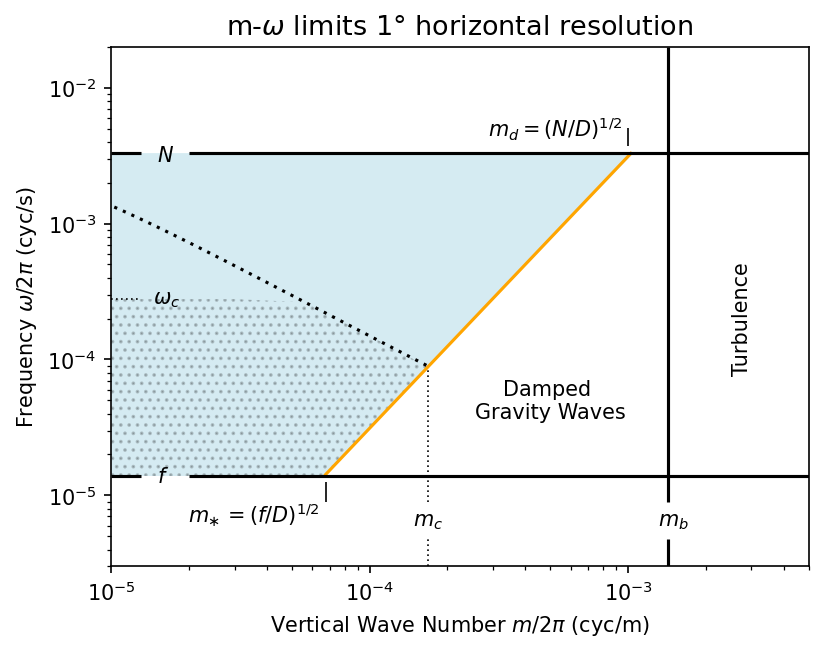

In [7]:
# Create figure canvas
fig = plt.figure(figsize=(6,4.5),dpi=150)
ax = plt.axes()
ax.set_xlim(1e-5,5e-3)
ax.set_ylim(3e-6,2e-2)
ax.set_xscale('log')
ax.set_yscale('log')

# ---------------------------------
# Plot lines and labels
# ---------------------------------

# Eq A1
x_eqA1 = np.logspace(np.log10(np.sqrt(2*np.pi*f/D)/(2*np.pi)+1e-6),np.log10(np.sqrt(2*np.pi*N/D)/(2*np.pi)),5) # X axis points
omega_chet_eqA1 = f*(x_eqA1/m_star)**2 
ax.plot(x_eqA1,omega_chet_eqA1,color='orange')

# Eq A5
x_eqA5 = np.logspace(-7,np.log10(m_c_nonrr)) # 
omega_chet_eqA5 = omega_from_m_omega_limit(N,h_c_nonrr,f,x_eqA5)
ax.plot(x_eqA5,omega_chet_eqA5,color='k',linestyle=(0,(1,2)))

ax.hlines(N,1e-5,1.3e-5, color='k') # short N lines
ax.hlines(N,2e-5,1e-2, color='k') # long N line
ax.text(1.5e-5, 3.2e-3, '$N$',
        horizontalalignment='left',
        verticalalignment='center',
        rotation=0)   

ax.hlines(f,1e-5,1.3e-5, color='k') # short f line
ax.hlines(f,2e-5,1e-2, color='k') # long f line
ax.text(1.5e-5, f, '$f$',
        horizontalalignment='left',
        verticalalignment='center',
        rotation=0)   

ax.vlines(m_b,1e-6,4.8e-6, color='k') # short mb 
ax.vlines(m_b,9e-6,2e-2, color='k') # long mb lineline
ax.text(1.5e-3, 6.5e-6, '$m_b$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)  

ax.vlines(m_star+1e-6,9e-6,f*0.9,color='k',linewidth=0.8) # m_star (added 1e-6 for slightly better alignment, as there is a tiny error between formula and value)
ax.text(m_star*0.96,7.2e-6, r'$m\!_\ast = (f/D)^{1/2}$',
        horizontalalignment='right',
        verticalalignment='center',
        rotation=0)   

ax.vlines(m_d,N+4e-4,N+1.75e-3,color='k',linewidth=0.8) # m_d 
ax.text(0.95*m_d,5e-3,'$m_d = (N/D)^{1/2}$',
        horizontalalignment='right',
        verticalalignment='center',
        rotation=0)   

ax.vlines(m_c_nonrr,1e-6,4.8e-6,color='k',linewidth=0.8,linestyle=(0,(1,2))) # m_c short
ax.vlines(m_c_nonrr,9e-6,f*(m_c_nonrr/m_star)**2,color='k',linewidth=0.8,linestyle=(0,(1,2))) # m_c long
ax.text(m_c_nonrr, 6.5e-6, '$m_c$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)   

ax.hlines(omega_c_nonrr,1e-5,1.3e-5,color='k',linewidth=0.8,linestyle=(0,(1,2))) # omega_c short
ax.text(1.45e-5, omega_c_nonrr, '$\omega_c$',
        horizontalalignment='left',
        verticalalignment='center',
        rotation=0)   

# ---------------------------------
# Shaded region
# ---------------------------------

### Blue region
m_diag_eqA5 = (h_c_nonrr*m_star*f)/(h_star*omega_c_nonrr)
polygon_points = [(1e-5, f), (1e-5, N),(m_d*1.05,N),(m_c_nonrr,f*(m_c_nonrr/m_star)**2), (m_star, f)] # Define the polygon points
polygon = plt.Polygon(polygon_points, facecolor='lightblue', alpha=0.5) # Add the shaded polygon
plt.gca().add_patch(polygon)

### Dotted region
## Points to define dotted shaded region edge that lines up with the dotted horizontal line
# Sample points along dotted line 
m_resolved_shaded_dotted = np.logspace(-5, -4,5)
omega_resolved_shaded_dotted = omega_from_m_omega_limit(N,h_c_nonrr,f,m_resolved_shaded_dotted)

polygon_points = [(1e-5, f), 
                  (1e-5, omega_c_nonrr),
                  (m_diag_eqA5,omega_c_nonrr),
                  (m_resolved_shaded_dotted[3],omega_resolved_shaded_dotted[3]),
                  (m_resolved_shaded_dotted[4],omega_resolved_shaded_dotted[4]),
                  (m_c_nonrr,f*(m_c_nonrr/m_star)**2), 
                  (m_star, f)] 

polygon = plt.Polygon(polygon_points,fill=False,alpha=0.2,hatch='...',linewidth=0,edgecolor='black') # Add the shaded polygon
plt.gca().add_patch(polygon)

# ---------------------------------
# Add annotations and labels
# ---------------------------------

ax.text(2.75e-3, 2e-4, 'Turbulence',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=90)    

ax.text(5e-4, 5e-5, 'Damped \nGravity Waves',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)    

# Axis labels
ax.set_xlabel('Vertical Wave Number $m/2\pi$ (cyc/m)')
ax.set_ylabel('Frequency $\omega$/2$\pi$ (cyc/s)')

# Title
plt.title("m-$\omega$ limits 1$\degree$ horizontal resolution",fontsize=13)

# ------------------------

# Global font controls
font = {'weight' : 'normal',
        'size'   : 13}
matplotlib.rc('font', **font)

if save: plt.savefig('./1deg_m_omega.png',bbox_inches='tight',dpi=150)

plt.show()

# RR m-omega

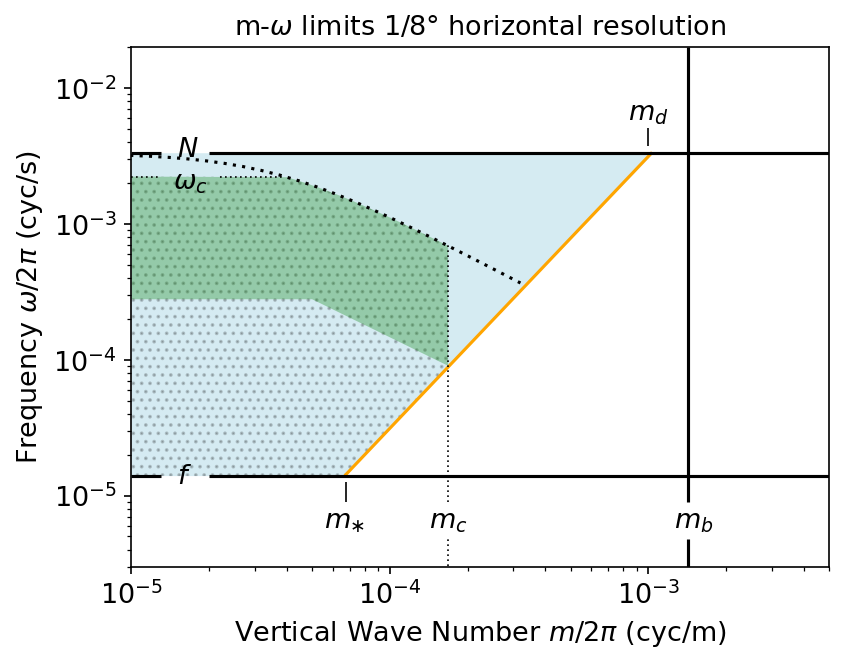

In [8]:
# Create figure canvas
fig = plt.figure(figsize=(6,4.5),dpi=150)
ax = plt.axes()
ax.set_xlim(1e-5,5e-3)
ax.set_ylim(3e-6,2e-2)
ax.set_xscale('log')
ax.set_yscale('log')

# ---------------------------------
# Plot lines and labels
# ---------------------------------

# Eq A1
x_eqA1 = np.logspace(np.log10(np.sqrt(2*np.pi*f/D)/(2*np.pi)+1e-6),np.log10(np.sqrt(2*np.pi*N/D)/(2*np.pi)),5) # X axis points
omega_chet_eqA1 = f*(x_eqA1/m_star)**2 
ax.plot(x_eqA1,omega_chet_eqA1,color='orange')
# ax.text(5e-4, 5e-4, '$\omega$ = $f(m/m\!_\ast)^2$',
#         horizontalalignment='center',
#         verticalalignment='center',
#         rotation=45.2)


# # Thick dotted due to dispersion relation
x_eqA5 = np.logspace(-7,np.log10(3.2e-4)) # 
omega_chet_eqA5 = omega_from_m_omega_limit(N,h_c_rr,f,x_eqA5)
ax.plot(x_eqA5,omega_chet_eqA5,color='k',linestyle=(0,(1,2)))


# ax.plot(x_eqA5,omega_chet_eqA5,color='k',linestyle=(0,(1,2)))


ax.hlines(N,1e-5,1.3e-5, color='k') # short N lines
ax.hlines(N,2e-5,1e-2, color='k') # long N line
ax.text(1.5e-5, 3.55e-3, '$N$',
        horizontalalignment='left',
        verticalalignment='center',
        rotation=0)   

ax.hlines(f,1e-5,1.3e-5, color='k') # short f line
ax.hlines(f,2e-5,1e-2, color='k') # long f line
ax.text(1.5e-5, f, '$f$',
        horizontalalignment='left',
        verticalalignment='center',
        rotation=0)   

ax.vlines(m_d,N+4e-4,N+1.75e-3,color='k',linewidth=0.8) # m_d 
ax.text(m_d,6.5e-3,'$m_d$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)   


# (added 1e-6 for slightly better alignment, as there is a tiny error between formula and value)
ax.vlines(m_star+1e-6,9e-6,0.9*f,color='k',linewidth=0.8) # m_star 
ax.text(m_star,6.5e-6, r'$m\!_\ast$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)   

ax.vlines(m_b,1e-6,4.8e-6, color='k') # short mb 
ax.vlines(m_b,9e-6,2e-2, color='k') # long mb lineline
ax.text(1.5e-3, 6.5e-6, '$m_b$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)  


ax.vlines(m_c_rr,1e-6,4.8e-6,color='k',linewidth=0.8,linestyle=(0,(1,2))) # m_c short
ax.vlines(m_c_rr,9e-6,7e-4,color='k',linewidth=0.8,linestyle=(0,(1,2))) # m_c long
ax.text(m_c_rr, 6.5e-6, '$m_c$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)   

ax.hlines(omega_c_rr,1e-5,1.3e-5,color='k',linewidth=0.8,linestyle=(0,(1,2))) # omega_c short
ax.hlines(omega_c_rr,2.2e-5,m_from_m_omega_limit(N,h_c_rr,f,omega_c_rr),color='k',linewidth=0.8,linestyle=(0,(1,2))) # omega_c long
ax.text(1.45e-5, omega_c_rr-2e-4, '$\omega_c$',
        horizontalalignment='left',
        verticalalignment='center',
        rotation=0)   


# ---------------------------------
# Shaded region
# ---------------------------------

# Intrinsic
m_diag_eqA5 = (h_c_rr*m_star*f)/(h_star*omega_c_rr)
polygon_points = [(1e-5, f), (1e-5, N),(m_d*1.05,N),(m_c_rr,f*(m_c_rr/m_star)**2), (m_star, f)] # Define the polygon points
polygon = plt.Polygon(polygon_points, facecolor='lightblue', alpha=0.5) # Add the shaded polygon
plt.gca().add_patch(polygon)

# # Resolved
# m_diag_eqA5 = (h_c_rr*m_star*f)/(h_star*omega_c_rr)
# polygon_points = [(1e-5, f), (1e-5, omega_c_rr),(m_diag_eqA5,omega_c_rr),(m_c_rr,f*(h_c_rr*m_star)/(h_star*m_c_rr)),(m_c_rr,f*(m_c_rr/m_star)**2), (m_star, f)] # Define the polygon points
# Points to define dotted shaded region edge that lines up with the dotted horizontal line
m_temp = m_from_m_omega_limit(N,h_c_rr,f,omega_c_rr)
m_resolved_shaded_dotted = np.logspace(np.log10(m_temp), np.log10(m_c_rr),6)
omega_resolved_shaded_dotted = omega_from_m_omega_limit(N,h_c_rr,f,m_resolved_shaded_dotted)

polygon_points = [(1e-5, f), (1e-5, omega_c_rr),(m_diag_eqA5,omega_c_rr),
        (m_resolved_shaded_dotted[0],omega_resolved_shaded_dotted[0]),
        (m_resolved_shaded_dotted[1],omega_resolved_shaded_dotted[1]),
        (m_resolved_shaded_dotted[2],omega_resolved_shaded_dotted[2]),
        (m_resolved_shaded_dotted[3],omega_resolved_shaded_dotted[3]),
        (m_resolved_shaded_dotted[4],omega_resolved_shaded_dotted[4]),
        (m_resolved_shaded_dotted[5],omega_resolved_shaded_dotted[5]),
        (m_c_rr,f*(m_c_rr/m_star)**2), (m_star, f)] # Define the polygon points

polygon = plt.Polygon(polygon_points,fill=False,alpha=0.2,hatch='...',linewidth=0,edgecolor='black') # Add the shaded polygon
plt.gca().add_patch(polygon)

# Extra spectrum

coords_extra = []

x_eqA5 = np.logspace(-5,np.log10(((h_c_rr*m_star**3)/h_star)**(1/3)),10) 
omega_chet_eqA5 = np.sqrt((N**2*h_c_rr**2 + f**2*x_eqA5**2)/(h_c_rr**2 + x_eqA5**2))
x_eqA5_nonrr = np.logspace(-5,np.log10(1.23e-4),10)
omega_chet_eqA5_nonrr = np.sqrt((N**2*h_c_nonrr**2 + f**2*x_eqA5**2)/(h_c_nonrr**2 + x_eqA5**2))

for i,j in zip(x_eqA5_nonrr,omega_chet_eqA5_nonrr):
        coords_extra.append((i,j))

coords_extra2 = []
x_temp = np.logspace(np.log10(4e-5),np.log10(m_c_rr),10)
omega_temp = omega_from_m_omega_limit(N,h_c_rr,f,x_temp)
for i,j in zip(x_temp,omega_temp):
        coords_extra2.append((i,j))
polygon_points = [[m_c_rr,9e-5],
                  [5e-5,omega_c_nonrr],
                  [1e-5,omega_c_nonrr],
                  [1e-5,omega_c_rr]] + coords_extra2 # Define the polygon points

polygon = plt.Polygon(polygon_points, facecolor='green', alpha=0.3) # Add the shaded polygon
plt.gca().add_patch(polygon)


# --------------
# Axis labels
ax.set_xlabel('Vertical Wave Number $m/2\pi$ (cyc/m)')
ax.set_ylabel('Frequency $\omega$/2$\pi$ (cyc/s)')

# Title
plt.title("m-$\omega$ limits 1/8$\degree$ horizontal resolution",fontsize=13)

# Global font controls
font = {'weight' : 'normal',
        'size'   : 13}
matplotlib.rc('font', **font)

if save: plt.savefig('./0.125deg_m_omega.png',bbox_inches='tight',dpi=150)
plt.show()

# 1$\degree$ h - omega


In [9]:
def omega_from_h_omega_limit(N,f,m_c,h):
    return np.sqrt((N**2*h**2 + f**2*m_c**2)/(h**2 + m_c**2))
    
def h_from_h_omega_limit(N,f,m_c,omega):
    return np.sqrt((omega**2*m_c**2 - f**2*m_c**2)/(N**2 - omega**2))

In [10]:
def omega_from_h_omega_complex_damped(h,omega):
    return f*(h/h_star)**(2/3)*((1-(omega/N)**2)/(1-(f/omega)**2))**(1/3) - omega

In [11]:
omega_list = np.logspace(-6, -2, 1000)
h_list = np.logspace(-7, np.log10(m_b), 100)

omega_root_list = []

min = 1e10

'''
Need to find roots implicitly as you cannot solve function explicitly for omega or h.
- Loop over h values - for every h value, there will be an omega value, such that omega_from_h_omega_complex_damped(h, omega) = 0
- Evaluate function omega_from_h_omega_complex_damped(h, omega)
- Find the minimum absolute value of the result (closest to 0)
- Store the value of omega

'''
for h_val in h_list:
    for omega in omega_list:
        result = omega_from_h_omega_complex_damped(h_val, omega)
        result_abs = np.abs(result)
        if (not np.isnan(result)) & (result_abs < min):
            # print(f"h: {h_val}, omega: {omega}, result: {result}, result_abs: {result_abs}")
            omega_root = omega
            min = np.abs(result)
    omega_root_list.append(omega_root)
    min = 1e10

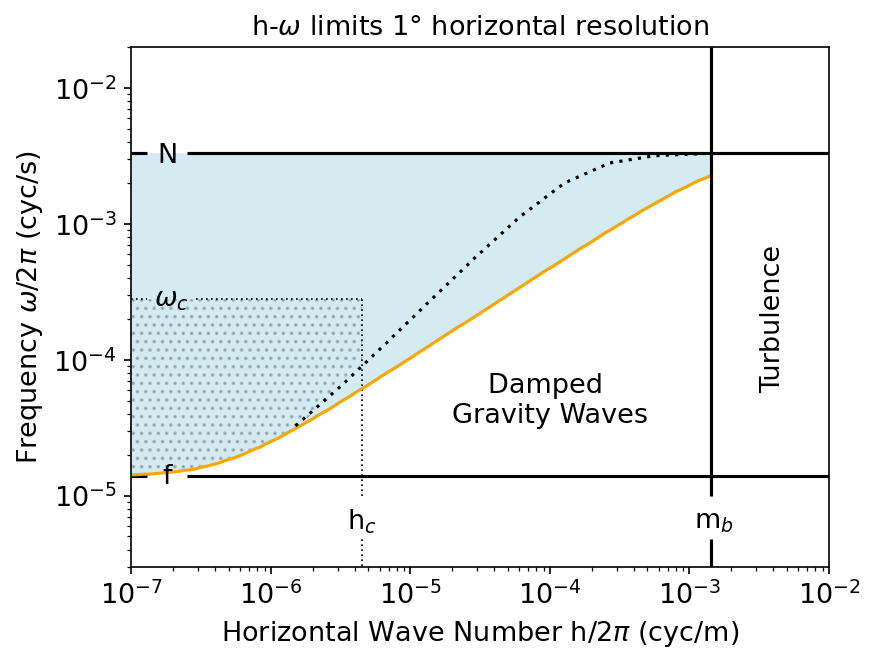

In [12]:
# Create figure canvas
fig = plt.figure(figsize=(6,4.5),dpi=150)
ax = plt.axes()
ax.set_xlim(1e-7,1e-2)
ax.set_ylim(3e-6,2e-2)
ax.set_xscale('log')
ax.set_yscale('log')

#--------------------------------------------
# Plot lines and labels
#--------------------------------------------
ax.hlines(N,1e-7,1.3e-7, color='k') # Short N lines
ax.hlines(N,2.5e-7,1e-2, color='k') # long N line
ax.text(1.8e-7, 3.2e-3, 'N',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)   

ax.hlines(f,1e-7,1.3e-7, color='k') # Short f line
ax.hlines(f,2.5e-7,1e-2, color='k') # long f line
ax.text(1.8e-7, f, 'f',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)  

ax.hlines(omega_c_nonrr,1e-7,1.3e-7, color='k',linewidth=0.8,linestyle=(0,(1,2))) # Short omega c line
ax.hlines(omega_c_nonrr,2.9e-7,h_c_nonrr, color='k',linewidth=0.8,linestyle=(0,(1,2))) # long omega c line
ax.text(1.45e-7, omega_c_nonrr, '$\omega_c$',
        horizontalalignment='left',
        verticalalignment='center',
        rotation=0)  

# mb line plotted below, to plot over orange line 


ax.vlines(h_c_nonrr,1e-6,4.8e-6, color='k',linewidth=0.8,linestyle=(0,(1,2))) # short hc
ax.vlines(h_c_nonrr,1e-5,omega_c_nonrr, color='k',linewidth=0.8,linestyle=(0,(1,2))) # long hc line
ax.text(h_c_nonrr, 6.5e-6, 'h$_c$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0) 

# ax.vlines(h_star,8e-6,1.26e-5,color='k',linewidth=0.8) # m_star (added 1e-6 for slightly better alignment, as there is a tiny error between formula and value)
# ax.text(h_star-1.5e-7,6.5e-6, r'$h\!_\ast = f\,m\!_\ast/N$',
#         horizontalalignment='left',
#         verticalalignment='center',
#         rotation=0)   

# ax.vlines(m_d,N+4e-4,N+1.75e-3,color='k',linewidth=0.8) # m_d 
# ax.text(m_d,6.5e-3,'$m_d$',
#         horizontalalignment='center',
#         verticalalignment='center',
#         rotation=0) 

# Eq A2 line
x_eqA2 = np.logspace(np.log10(h_star+0.1e-7),np.log10(m_d),10)
omega_chet_eqA2 = f*(x_eqA2/h_star)**(2/3)
# ax.plot(x_eqA2,omega_chet_eqA2,color='k')
ax.plot(h_list, omega_root_list, color='orange', label='Complex Damped Solution') # Plot the complex damped solution
# ax.text(3e-5, 2e-4, r'$\omega$ = $f(h/h\!_\ast)^{2/3}$',
#         horizontalalignment='center',
#         verticalalignment='center',
#         rotation=31.5)


ax.vlines(m_b,1e-6,4.8e-6, color='k') # short mb 
ax.vlines(m_b,1e-5,2e-2, color='k') # long mb lineline
ax.text(1.5e-3, 6.5e-6, 'm$_b$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)  

# Eq A6 thick dotted line
x_eq_A6_upper = h_from_h_omega_limit(N,f,m_c_nonrr,0.99*N)
x_eqA6 = np.logspace(np.log10(1.5e-6),np.log10(x_eq_A6_upper),10)
omega_chet_eqA6 = omega_from_h_omega_limit(N,f,m_c_nonrr,x_eqA6)
ax.plot(x_eqA6,omega_chet_eqA6,color='k',linestyle=(0,(1,2)))
# ax.text(2e-5, 6.5e-4, r'$\omega$ = $N\,h\,/\,m_c$',
#         horizontalalignment='center',
#         verticalalignment='center',
#         rotation=46)


# ---------------------------------
# Add annotations
# ---------------------------------

ax.text(4e-3, 2e-4, 'Turbulence',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=90)     

ax.text(1e-4, 5e-5, 'Damped \nGravity Waves',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)    
  
# ---------------------------------
# Shaded region
# ---------------------------------

# Intrinsic

coords_intrinsic = []
for i,j in zip(omega_root_list[0::10],h_list[0::10]):
    coords_intrinsic.append([j,i])
coords_intrinsic.append([h_list[-1],omega_root_list[-1]])  # Add the last point to ensure the line is closed

polygon_points = coords_intrinsic + [(m_b,N),(1e-7, N)] # Define the polygon points
polygon = plt.Polygon(polygon_points, facecolor='lightblue', alpha=0.5) # Add the shaded polygon
plt.gca().add_patch(polygon)

# Resolved

coords_resolved = []
for i,j in zip(omega_root_list[0:30],h_list[0:30]):
    coords_resolved.append([j,i])
    
omega_diag_eqA6 = f*(h_c_nonrr*m_star)/(h_star*m_c_nonrr)
polygon_points = [(1e-7, f)] + \
                coords_resolved + \
                [(h_c_nonrr, 1e-4), (h_c_nonrr,omega_c_nonrr),(1e-7,omega_c_nonrr)] # Define the polygon points
polygon = plt.Polygon(polygon_points,fill=False,alpha=0.2,hatch='...',linewidth=0,edgecolor='black') # Add the shaded polygon
plt.gca().add_patch(polygon)


#--------------

# Axis labels
ax.set_xlabel('Horizontal Wave Number h/2$\pi$ (cyc/m)')
ax.set_ylabel('Frequency $\omega$/2$\pi$ (cyc/s)')
plt.title("h-$\omega$ limits 1$\degree$ horizontal resolution",fontsize=13)



# Global font controls
font = {'weight' : 'normal',
        'size'   : 13}
matplotlib.rc('font', **font)
if save: plt.savefig('./1deg_h_omega.png',bbox_inches='tight',dpi=150)
plt.show()

# RR h - omega


In [13]:
index1 = np.argmin(np.abs(h_list - h_c_nonrr))# Find the index of the closest value to h_c_nonrr in h_list
index2 = np.argmin(np.abs(h_list -h_c_rr))

In [14]:
coords_extra = [] 
omega_lim_list = omega_from_h_omega_limit(N,f,m_c_nonrr,h_list[index1:index2+1]) # Calculate omega for h_c_nonrr

for i,j in zip(omega_lim_list,h_list[index1:index2+1]):
    coords_extra.append([j,i])

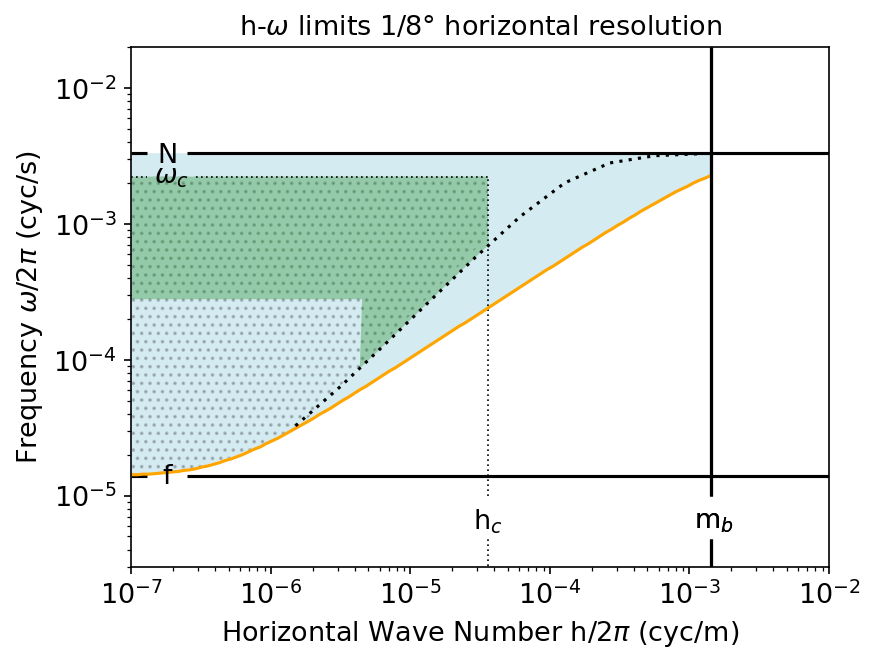

In [15]:
# Create figure canvas
fig = plt.figure(figsize=(6,4.5),dpi=150)
ax = plt.axes()
ax.set_xlim(1e-7,1e-2)
ax.set_ylim(3e-6,2e-2)
ax.set_xscale('log')
ax.set_yscale('log')

#--------------------------------------------
# Plot lines and labels
#--------------------------------------------
ax.hlines(N,1e-7,1.3e-7, color='k') # Short N lines
ax.hlines(N,2.5e-7,1e-2, color='k') # long N line
ax.text(1.8e-7, 3.2e-3, 'N',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)   

ax.hlines(f,1e-7,1.3e-7, color='k') # Short f line
ax.hlines(f,2.5e-7,1e-2, color='k') # long f line
ax.text(1.8e-7, f, 'f',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)  

ax.hlines(omega_c_rr,1e-7,1.3e-7, color='k',linewidth=0.8,linestyle=(0,(1,2))) # Short omega c line
ax.hlines(omega_c_rr,2.9e-7,h_c_rr, color='k',linewidth=0.8,linestyle=(0,(1,2))) # long omega c line
ax.text(1.45e-7, omega_c_rr, '$\omega_c$',
        horizontalalignment='left',
        verticalalignment='center',
        rotation=0)  

ax.vlines(m_b,1e-6,4.8e-6, color='k') # short mb 
ax.vlines(m_b,1e-5,2e-2, color='k') # long mb lineline
ax.text(1.5e-3, 6.5e-6, 'm$_b$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)  

ax.vlines(h_c_rr,1e-6,4.8e-6, color='k',linewidth=0.8,linestyle=(0,(1,2))) # short hc
ax.vlines(h_c_rr,1e-5,omega_c_rr, color='k',linewidth=0.8,linestyle=(0,(1,2))) # long hc line
ax.text(h_c_rr, 6.5e-6, 'h$_c$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0) 

# Eq A2 line
x_eqA2 = np.logspace(np.log10(h_star+0.1e-7),np.log10(m_d),10)
omega_chet_eqA2 = f*(x_eqA2/h_star)**(2/3)
# ax.plot(x_eqA2,omega_chet_eqA2,color='k')
ax.plot(h_list, omega_root_list, color='orange', label='Complex Damped Solution') # Plot the complex damped solution
# ax.text(3e-5, 2e-4, r'$\omega$ = $f(h/h\!_\ast)^{2/3}$',
        # horizontalalignment='center',
        # verticalalignment='center',
        # rotation=31.5)


ax.vlines(m_b,1e-6,4.8e-6, color='k') # short mb 
ax.vlines(m_b,1e-5,2e-2, color='k') # long mb lineline
ax.text(1.5e-3, 6.5e-6, 'm$_b$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)  

# Eq A6 line
x_eq_A6_upper = h_from_h_omega_limit(N,f,m_c_nonrr,0.99*N)
x_eqA6 = np.logspace(np.log10(1.5e-6),np.log10(x_eq_A6_upper),10)
omega_chet_eqA6 = omega_from_h_omega_limit(N,f,m_c_nonrr,x_eqA6)
ax.plot(x_eqA6,omega_chet_eqA6,color='k',linestyle=(0,(1,2)))


# ---------------------------------
# Shaded region
# ---------------------------------

# Intrinsic
polygon_points = coords_intrinsic + [(m_b,N),(1e-7, N)] # Define the polygon points
polygon = plt.Polygon(polygon_points, facecolor='lightblue', alpha=0.5) # Add the shaded polygon
plt.gca().add_patch(polygon)


# Resolved

coords_resolved = []
for i,j in zip(omega_root_list[0:30],h_list[0:30]):
    coords_resolved.append([j,i])
    

omega_diag_eqA6 = f*(h_c_rr*m_star)/(h_star*m_c_rr)

# Define the polygon points
polygon_points = [(1e-7, f)] + \
                  coords_resolved + \
                 [(h_c_rr,8e-4), (h_c_rr,omega_c_rr),
                 (1e-7,omega_c_rr)] 
polygon = plt.Polygon(polygon_points,fill=False,alpha=0.2,hatch='...',linewidth=0,edgecolor='black') # Add the shaded polygon
plt.gca().add_patch(polygon)

# Extra resolved by high res
polygon_points = coords_extra + [(h_c_rr,omega_c_rr), (1e-7,omega_c_rr), (1e-7,omega_c_nonrr), (h_c_nonrr,omega_c_nonrr)] # Define the polygon points
polygon = plt.Polygon(polygon_points, facecolor='green', alpha=0.3) # Add the shaded polygon
plt.gca().add_patch(polygon)

#--------------

# Axis labels
ax.set_xlabel('Horizontal Wave Number h/2$\pi$ (cyc/m)')
ax.set_ylabel('Frequency $\omega$/2$\pi$ (cyc/s)')
plt.title("h-$\omega$ limits 1/8$\degree$ horizontal resolution",fontsize=13)

# Global font controls
font = {'weight' : 'normal',
        'size'   : 13}
matplotlib.rc('font', **font)

if save: plt.savefig('./media/0.125deg_h_omega.png',bbox_inches='tight',dpi=150)
plt.show()

# 1$\degree$ h - m


In [5]:
def m_from_h_m_complex_damped(h,m):
    return m_star*(h/h_star)**(1/3)*( ( 1 + ((f*m)/(N*h))**2 ) / ( 1 + (h/m)**2) )**(1/6) - m

In [6]:
m_list = np.logspace(-6, -2, 1000)
h_list = np.logspace(np.log10(2.5e-7), np.log10(6.2e-4), 1000)

m_root_list = []

min = 1e10

'''
Need to find roots implicitly as you cannot solve function explicitly for omega or h.
- Loop over h values - for every h value, there will be an omega value, such that omega_from_h_omega_complex_damped(h, omega) = 0
- Evaluate function omega_from_h_omega_complex_damped(h, omega)
- Find the minimum absolute value of the result (closest to 0)
- Store the value of omega

'''
for h_val in h_list:
    for m_val in m_list:
        result = m_from_h_m_complex_damped(h_val, m_val)
        result_abs = np.abs(result)
        if (not np.isnan(result)) & (result_abs < min):
            # print(f"h_val: {m_val}, omega: {omega}, result: {result}, result_abs: {result_abs}")
            m_root = m_val
            min = np.abs(result)
    m_root_list.append(m_root)
    min = 1e10

In [7]:
def m_from_m_h_limit(h,N,omega_c,f):
    return h*np.sqrt((N**2 - omega_c**2)/(omega_c**2 - f**2))

def h_from_m_h_limit(m,N,omega_c,f):
    return m/np.sqrt((N**2 - omega_c**2)/(omega_c**2 - f**2))

In [8]:
coords_intrinsic = [] 

for i,j in zip(m_root_list[0::10],h_list[0::10]):
    coords_intrinsic.append([j,i])
coords_intrinsic.append([h_list[-1],m_root_list[-1]])  # Add the last point to ensure the line is closed

In [9]:
coords_resolved = [] 

index = np.argmin(np.abs(h_list-h_c_nonrr))
for i,j in zip(m_root_list[0:index+1:],h_list[0:index+1:]):
    coords_resolved.append([j,i])

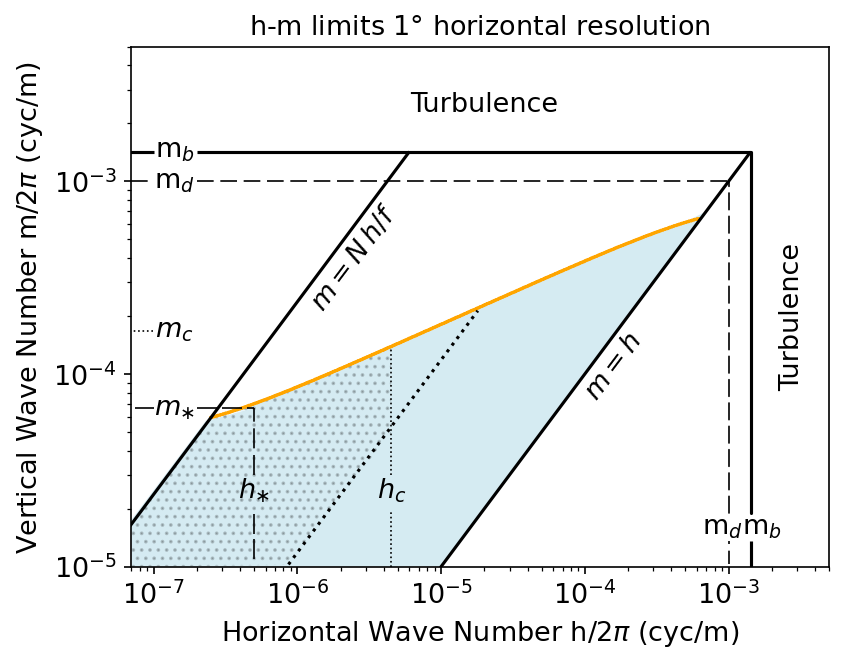

In [20]:
# Create figure canvas

fig = plt.figure(figsize=(6,4.5),dpi=150)
ax = plt.axes()
ax.set_xlim(7e-8,5e-3)
ax.set_ylim(1e-5,5e-3)
ax.set_xscale('log')
ax.set_yscale('log')

# --------------------------------
# Plot lines and labels
# --------------------------------


# A3 diagonal (at the top so black lines go over it)
x_eqA3 = np.logspace(np.log10(h_star),np.log10(m_d),5)
m_chet_eqA3 = m_star*(x_eqA3/h_star)**(1/3)
ax.plot(h_list, m_root_list, color='orange', label='Complex Damped Solution') # Plot the complex damped solution
# ax.plot(x_eqA3,m_chet_eqA3,color='k')
# ax.text(2e-5, 3.5e-4, r'$m=m\!_\ast(h/h\!_\ast)^{1/3}$',
#         horizontalalignment='center',
#         verticalalignment='center',
#         rotation=24.5)  

# ax.hlines(f,1e-7,1.3e-7, color='k') # short 
# ax.hlines(f,2.2e-7,1e-2, color='k') # long

# m_d horizontal

# m_b horizontal
ax.hlines(m_b,1e-8,1e-7, color='k') # short 
ax.hlines(m_b,2e-7,m_b, color='k') # long 
ax.text(1.4e-7, 1.45e-3, 'm$_b$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)  

# m_d horizontal
ax.hlines(m_d,7e-8,1e-7, color='k',linestyle=(0,(10,4)),linewidth=0.8) # short 
ax.hlines(m_d,2e-7,m_d, color='k',linestyle=(0,(10,4)),linewidth=0.8) # long 
ax.text(1.4e-7, m_d, 'm$_d$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)  

# m_star horizontal
ax.hlines(m_star,1e-8,1e-7, color='k',linewidth=0.8,linestyle=(0,(12,3))) 
ax.hlines(m_star,2e-7,h_star, color='k',linewidth=0.8,linestyle=(0,(12,3))) 
ax.text(1.4e-7, m_star, r'$m\!_\ast$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)  

# m_c horizontal
ax.hlines(m_c_nonrr,1e-8,1e-7, color='k',linewidth=0.8,linestyle=':') 
# ax.hlines(m_c_nonrr,2e-7,h_c_nonrr, color='k',linewidth=0.8,linestyle=':') 
ax.text(1.4e-7, m_c_nonrr, r'$m_c$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)  

# h_star vertical
ax.vlines(h_star,1.1e-5,1.95e-5, color='k',linewidth=0.8,linestyle=(0,(12,3))) # short 
ax.vlines(h_star,3e-5,m_star, color='k',linewidth=0.8,linestyle=(0,(12,4))) # long 
ax.text(h_star, 2.5e-5, r'$h\!_\ast$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)  

# h_c vertical
y_hc_upper = m_star*(h_c_nonrr/h_star)**(1/3)
ax.vlines(h_c_nonrr,1e-5,1.95e-5, color='k',linewidth=0.8,linestyle=':') # short 
ax.vlines(h_c_nonrr,3e-5,y_hc_upper, color='k',linewidth=0.8,linestyle=':') # long 
ax.text(h_c_nonrr, 2.5e-5, r'$h_c$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)  


# m_b vertical
ax.vlines(m_b,1.5e-6,1.35e-5, color='k') # short 
ax.vlines(m_b,1.9e-5,m_b, color='k',capstyle='round') # long 
ax.text(m_b*1.2, 1.6e-5, 'm$_b$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)   

# m_d vertical
ax.vlines(m_d,1.5e-6,1.35e-5, color='k',linestyle=(0,(8,4)),linewidth=0.8) # short 
ax.vlines(m_d,1.9e-5,m_d, color='k',capstyle='round',linestyle=(0,(10,4)),linewidth=0.8) # long 
ax.text(m_d*0.9, 1.6e-5, 'm$_d$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)   

# m = h diagonal (omega = f)
x_m_h = np.logspace(-5,np.log10(m_b),10)
ax.plot(0.99*x_m_h,0.99*x_m_h,color='k',solid_capstyle='round')
ax.text(1.6e-4, 1.1e-4, r'$m=h$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=53)  

# m = Nh/f diag (omega = N)
x_nh_f_upper = f*m_b/N
x_nh_f_upper = f*m_b/N

x_nh_f = np.logspace(-9,np.log10(x_nh_f_upper),10)
y_nh_f = N*x_nh_f/f
ax.plot(x_nh_f,y_nh_f,color='k',solid_capstyle='butt')
ax.text(2.5e-6, 4e-4, r'$m=N\,h/f$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=53)  

# A7 diagonal
x_eqA7_lower = 1e-7
x_eqA7_upper = h_star*(omega_c_nonrr/f)**(3/2)
x_eqA7 = np.logspace(np.log10(x_eqA7_lower), np.log10(1.8e-5),5)
# m_chet_eqA7 = m_star*(f*x_eqA7)/(omega_c_nonrr*h_star)
# m_chet_eqA7 = N*x_eqA7/omega_c_nonrr
m_chet_eqA7 = m_from_m_h_limit(x_eqA7,N,omega_c_nonrr,f)
ax.plot(x_eqA7,m_chet_eqA7,color='k',solid_capstyle='round',linestyle=':')
 
# ax.text(7e-5, 1.1e-4, r'$m \simeq N\,h\,/\,\omega_c$',
#         horizontalalignment='center',
#         verticalalignment='center',
#         rotation=53)   
# --------------------------------
# Add annotations
# --------------------------------

# ax.text(m_c_rr, 6.5e-6, 'm$_c$',
#         horizontalalignment='center',
#         verticalalignment='center',
#         rotation=0)   

# ax.text(4e-4, 8e-4, '$\omega$ = f(m/m*)$^2$',
#         horizontalalignment='center',
#         verticalalignment='center',
#         rotation=47)

ax.text(2.75e-3, 2e-4, 'Turbulence',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=90)    

ax.text(2e-5, 2.5e-3, 'Turbulence',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)    

# ax.text(1e-6, 1e-3, 'Undamped \nGravity Waves',
#         horizontalalignment='center',
#         verticalalignment='center',
#         rotation=0)    

# ax.text(2e-4, 3e-5, 'Damped \nGravity Waves',
#         horizontalalignment='center',
#         verticalalignment='center',
#         rotation=0)    
  
# Intrinsic spectrum
polygon_points = [(7e-8, 1e-5), (7e-8,1.75e-5), (2.3e-7,5.7e-5), (h_star, m_star)]+coords_intrinsic[:-3]+[(7e-4,7e-4),(1e-5,1e-5)] # Define the polygon points
polygon = plt.Polygon(polygon_points, facecolor='lightblue', alpha=0.5) # Add the shaded polygon
plt.gca().add_patch(polygon)

# Resolved spectrum
polygon_points = [(7e-8, 1e-5),(7e-8,N*7e-8/f), (2.5e-7,6e-5), (h_star, m_star)] + coords_resolved + [(h_c_nonrr,5e-5),(8.5e-7,1.02e-5)] # Define the polygon points
polygon = plt.Polygon(polygon_points,fill=False,alpha=0.2,hatch='...',linewidth=0,edgecolor='black') # Add the shaded polygon
plt.gca().add_patch(polygon)

# Axis labels
ax.set_xlabel('Horizontal Wave Number h/2$\pi$ (cyc/m)')
ax.set_ylabel('Vertical Wave Number m/2$\pi$ (cyc/m)')
plt.title("h-m limits 1$\degree$ horizontal resolution",fontsize=13)
# Global font controls
font = {'weight' : 'normal',
        'size'   : 13}
matplotlib.rc('font', **font)

if save: plt.savefig('./media/1deg_h_m.png',bbox_inches='tight',dpi=150)
plt.show()

# RR h - m 

In [21]:
coords_resolved = [] 

index = np.argmin(np.abs(np.array(m_root_list)-m_c_rr))
for i,j in zip(m_root_list[0:index+1:],h_list[0:index+1:]):
    coords_resolved.append([j,i])

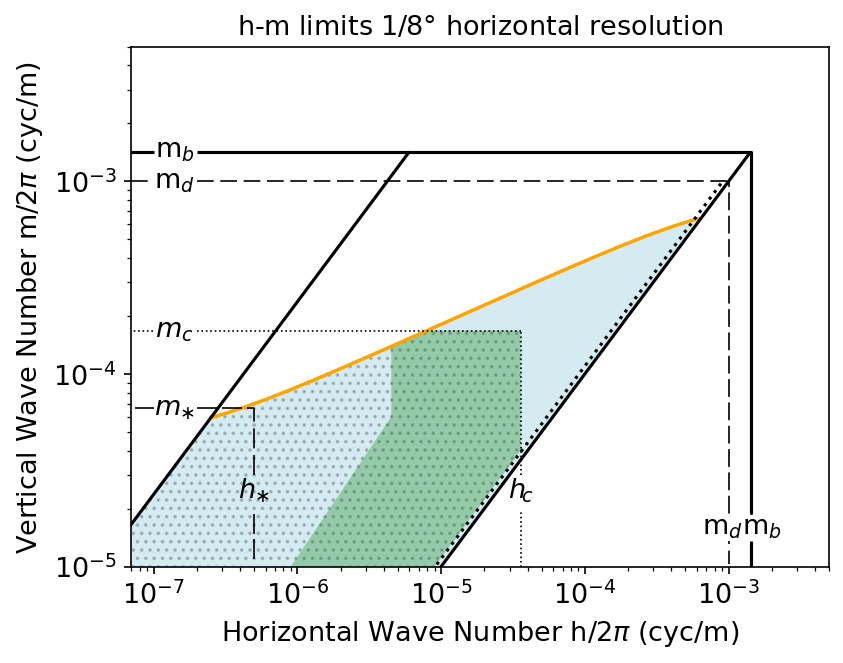

In [44]:

# Create figure canvas
fig = plt.figure(figsize=(6,4.5),dpi=150)
ax = plt.axes()
ax.set_xlim(7e-8,5e-3)
ax.set_ylim(1e-5,5e-3)
ax.set_xscale('log')
ax.set_yscale('log')

# --------------------------------
# Plot lines and labels
# --------------------------------

# A3 diagonal 
x_eqA3 = np.logspace(np.log10(h_star+0.1e-7),np.log10(m_d),5)
m_chet_eqA3 = m_star*(x_eqA3/h_star)**(1/3)
ax.plot(h_list, m_root_list, color='orange', label='Complex Damped Solution') # Plot the complex damped solution
# ax.plot(x_eqA3,m_chet_eqA3,color='k')
# ax.text(2e-5, 3.5e-4, r'$m=m\!_\ast(h/h\!_\ast)^{1/3}$',
#         horizontalalignment='center',
#         verticalalignment='center',
#         rotation=24.5)  


# ax.hlines(f,1e-7,1.3e-7, color='k') # short 
# ax.hlines(f,2.2e-7,1e-2, color='k') # long

# m_d horizontal

# m_b horizontal
ax.hlines(m_b,1e-8,1e-7, color='k') # short 
ax.hlines(m_b,2e-7,m_b, color='k') # long 
ax.text(1.4e-7, 1.45e-3, 'm$_b$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)  

# m_d horizontal
ax.hlines(m_d,7e-8,1e-7, color='k',linestyle=(0,(10,4)),linewidth=0.8) # short 
ax.hlines(m_d,2e-7,m_d, color='k',linestyle=(0,(10,4)),linewidth=0.8) # long 
ax.text(1.4e-7, m_d, 'm$_d$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)  

# m_star horizontal
ax.hlines(m_star,1e-8,1e-7, color='k',linewidth=0.8,linestyle=(0,(12,3))) 
ax.hlines(m_star,2e-7,h_star, color='k',linewidth=0.8,linestyle=(0,(12,3))) 
ax.text(1.4e-7, m_star, r'$m\!_\ast$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)  

# m_c horizontal
ax.hlines(m_c_rr,1e-8,1e-7, color='k',linewidth=0.8,linestyle=':') 
ax.hlines(m_c_rr,2e-7,h_c_rr, color='k',linewidth=0.8,linestyle=':') 
ax.text(1.4e-7, m_c_rr, r'$m_c$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)  

# h_star vertical
ax.vlines(h_star,1.1e-5,1.95e-5, color='k',linewidth=0.8,linestyle=(0,(12,3))) # short 
ax.vlines(h_star,3e-5,m_star, color='k',linewidth=0.8,linestyle=(0,(12,4))) # long 
ax.text(h_star, 2.5e-5, r'$h\!_\ast$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)  

# h_c vertical
ax.vlines(h_c_rr,1e-5,1.95e-5, color='k',linewidth=0.8,linestyle=':') # short 
ax.vlines(h_c_rr,3e-5,m_c_rr, color='k',linewidth=0.8,linestyle=':') # long 
ax.text(h_c_rr, 2.5e-5, r'$h\!_c$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)  


# m_b vertical
ax.vlines(m_b,1.5e-6,1.35e-5, color='k') # short 
ax.vlines(m_b,1.9e-5,m_b, color='k',capstyle='round') # long 
ax.text(m_b*1.2, 1.6e-5, 'm$_b$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)   

# m_d vertical
ax.vlines(m_d,1.5e-6,1.35e-5, color='k',linestyle=(0,(8,4)),linewidth=0.8) # short 
ax.vlines(m_d,1.9e-5,m_d, color='k',capstyle='round',linestyle=(0,(10,4)),linewidth=0.8) # long 
ax.text(m_d*0.9, 1.6e-5, 'm$_d$',
        horizontalalignment='center',
        verticalalignment='center',
        rotation=0)   

# m = h diagonal (omega = f)
x_m_h = np.logspace(-5,np.log10(m_b),10)
ax.plot(0.99*x_m_h,0.99*x_m_h,color='k',solid_capstyle='round')
# ax.text(3e-4, 4e-4, r'$m=h$',
#         horizontalalignment='center',
#         verticalalignment='center',
#         rotation=53)  

# m = Nh/f diag (omega = N)
x_nh_f_upper = f*m_b/N
x_nh_f = np.logspace(-9,np.log10(x_nh_f_upper),10)
y_nh_f = N*x_nh_f/f
ax.plot(x_nh_f,y_nh_f,color='k',solid_capstyle='butt')
# ax.text(1.25e-6, 4e-4, r'$m=N\,h/f$',
#         horizontalalignment='center',
#         verticalalignment='center',
#         rotation=53)  


# A7 diagonal
x_eqA7_lower = 1e-7
x_eqA7_upper = 0.9e-3 #h_star*(omega_c_rr/f)**(3/2)
x_eqA7 = np.logspace(np.log10(x_eqA7_lower), np.log10(x_eqA7_upper),5)
m_chet_eqA7 = m_from_m_h_limit(x_eqA7,N,omega_c_rr,f)
ax.plot(x_eqA7,m_chet_eqA7,color='k',solid_capstyle='round',linestyle=':')
# ax.text(2e-5, 3.5e-4, r'$m=m\!_\ast(h/h\!_\ast)^{1/3}$',
#         horizontalalignment='center',
#         verticalalignment='center',
#         rotation=24.5)   

# --------------------------------
# Add annotations
# --------------------------------

# ax.text(m_c_rr, 6.5e-6, 'm$_c$',
#         horizontalalignment='center',
#         verticalalignment='center',
#         rotation=0)   

# ax.text(4e-4, 8e-4, '$\omega$ = f(m/m*)$^2$',
#         horizontalalignment='center',
#         verticalalignment='center',
#         rotation=47)

# ax.text(2.75e-3, 2e-4, 'Turbulence',
#         horizontalalignment='center',
#         verticalalignment='center',
#         rotation=90)    

# ax.text(2e-5, 2.5e-3, 'Turbulence',
#         horizontalalignment='center',
#         verticalalignment='center',
#         rotation=0)    

# ax.text(1e-6, 1e-3, 'Undamped \nGravity Waves',
#         horizontalalignment='center',
#         verticalalignment='center',
#         rotation=0)    

# ax.text(2e-4, 3e-5, 'Damped \nGravity Waves',
#         horizontalalignment='center',
#         verticalalignment='center',
#         rotation=0)    
  
# Intrinsic spectrum
polygon_points = [(7e-8, 1e-5),(7e-8,N*7e-8/f), (2.5e-7,6e-5), (h_star, m_star)]+coords_intrinsic+[(1e-5,1e-5)] # Define the polygon points
polygon = plt.Polygon(polygon_points, facecolor='lightblue', alpha=0.5) # Add the shaded polygon
plt.gca().add_patch(polygon)


# Resolved spectrum
# h_a5 = (1e-5*omega_c_rr*h_star)/(m_star*f)
# h_mc_a3 = (m_c_rr/m_star)**3 * h_star

# m_temp = m_from_m_h_limit(h_c_rr,N,omega_c_rr,f)
# h_temp = h_from_m_h_limit(1e-5,N,omega_c_rr,f)

polygon_points = [(7e-8, 1e-5),(7e-8,N*7e-8/f), (2.5e-7,6e-5), (h_star, m_star)] + coords_resolved + [(h_c_rr,m_c_rr),(h_c_rr,4e-5), (9e-6,1e-5),(8.5e-7,1.02e-5)] # Define the polygon points
polygon = plt.Polygon(polygon_points,fill=False,alpha=0.2,hatch='...',linewidth=0,edgecolor='black') # Add the shaded polygon
plt.gca().add_patch(polygon)

# Extra spectrum
polygon_points = [(9e-7,1e-5),(h_c_nonrr, 6e-5), (h_c_nonrr,1.4e-4), (8e-6,m_c_rr), (h_c_rr,m_c_rr),(h_c_rr,4e-5), (9e-6,1e-5)] # Define the polygon points
polygon = plt.Polygon(polygon_points,facecolor='green', alpha=0.3) # Add the shaded polygon
plt.gca().add_patch(polygon)


# Axis labels
ax.set_xlabel('Horizontal Wave Number h/2$\pi$ (cyc/m)')
ax.set_ylabel('Vertical Wave Number m/2$\pi$ (cyc/m)')
plt.title("h-m limits 1/8$\degree$ horizontal resolution",fontsize=13)
# Global font controls
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 13}
matplotlib.rc('font', **font)

if save: plt.savefig('./media/0.125deg_h_m.png',bbox_inches='tight',dpi=150)
plt.show()